# Progetto DIA - A.A 2025/26

Autori: Justin Carideo (justin.carideo@studio.unibo.it), Laura Bertozzi ()

# Setup

In [133]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
import seaborn as sns

sns.set_theme(style="whitegrid")

Importiamo i dataset presi dal sito https://www.kaggle.com. Questi due dataset fanno riferimento a dati in ambito agricolo, in particolare:
1) **Crop Dataset** -> dataset incentrato su aspetti ambientali per individuare il tipo di coltura dato il tipo di terreno e nutrienti presenti (https://www.kaggle.com/datasets/snmahsa/soil-nutrients)
2) **Fertilizer DataSet** -> dataset incentrato sullo stesso campo ma che vuole individuare il tipo di fertilizzante dato il tipo di terreno e la coltura presente. (https://www.kaggle.com/datasets/nishchalchandel/fertilizer-recommendation)

In [134]:
import kaggle
import os
import os.path\

CROP_DATASET_ID = "varshitanalluri/crop-recommendation-dataset"
FERTILIZER_DATASET_ID = "nishchalchandel/fertilizer-recommendation"

BASE_DOWNLOAD_DIR = "data"

CROP_DATASET_DIR = os.path.join(BASE_DOWNLOAD_DIR, "dataset_1")
FERTILIZER_DATASET_DIR = os.path.join(BASE_DOWNLOAD_DIR, "dataset_2")

os.makedirs(BASE_DOWNLOAD_DIR, exist_ok=True) # crea la directory se non esiste


def download_kaggle_dataset(dataset_id, dataset_path):
    os.makedirs(dataset_path, exist_ok=True)
    if not os.listdir(dataset_path):
        print(f"Download {dataset_id} in {dataset_path}")
        kaggle.api.dataset_download_files(
            dataset_id,
            path=dataset_path,
            unzip=True
        )
    else:
        print(f"Dataset already in specified path")

download_kaggle_dataset(CROP_DATASET_ID, CROP_DATASET_DIR)
download_kaggle_dataset(FERTILIZER_DATASET_ID, FERTILIZER_DATASET_DIR)

CROP_DATASET_PATH = os.path.join(CROP_DATASET_DIR, "Crop_recommendation.csv")
FERTILIZER_DATASET_PATH = os.path.join(FERTILIZER_DATASET_DIR, "fertilizer_recommendation_dataset.csv")

Dataset already in specified path
Dataset already in specified path


Creiamo i dataframe di entrambi i dataset:

In [135]:
crop_df = pd.read_csv(CROP_DATASET_PATH)
fertilizer_df = pd.read_csv(FERTILIZER_DATASET_PATH)

Ora che abbiamo ottenuto i dataset dobbiamo decidere che modello attuare su questi dataset e visto che non hanno indici univoci per riga possiamo attuare una **recommendation** per la predizione di colture e fertilizzanti. In particolare potremmo ragionare con una sorta di *pipeline* dove i dati di entrambi vengono utilizzati per ottenere una classificazione della coltura desiderata date le informazioni relative al terreno e utilizzare i dati ottenuti per calcolare anche il tipo di fertilizzante da attuare.

Questa è una analisi a priori, una volta svolta l'*analisi esplorativa* si potrà procedere con la costruzione del modello.

# Analisi Esplorativa

In [136]:
crop_df

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,Coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,Coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,Coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,Coffee


In [137]:
fertilizer_df

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
3095,23.486430,0.531191,46.412228,6.733584,56.534283,146.111078,81.389366,1.602913,Neutral Soil,watermelon,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3096,24.289508,0.736699,63.068103,6.372709,56.358005,49.003277,46.695889,1.473656,Peaty Soil,watermelon,DAP,"Rich in phosphorus, essential for root develop..."
3097,23.945488,0.520513,41.344590,7.051515,55.738905,148.567285,90.057021,1.455045,Neutral Soil,watermelon,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3098,26.368604,0.547436,33.106012,6.615922,57.711705,96.662953,59.531473,0.614487,Acidic Soil,watermelon,Compost,Enhances organic matter and improves soil stru...


In [138]:
crop_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [139]:
fertilizer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   str    
 9   Crop         3100 non-null   str    
 10  Fertilizer   3100 non-null   str    
 11  Remark       3100 non-null   str    
dtypes: float64(8), str(4)
memory usage: 290.8 KB


In [140]:
crop_df.describe()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [141]:
fertilizer_df.describe()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon
count,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000
mean,27.271096,0.600763,111.024949,6.379775,61.278480,69.582850,69.721167,1.474325
std,9.114450,0.144947,77.151880,0.957103,10.186410,42.226712,35.304241,0.698300
min,4.011486,0.227436,-85.709593,3.448974,35.527718,-37.649739,-20.509108,-0.280560
25%,22.408505,0.493595,61.283985,5.860489,54.835715,43.039260,49.992405,0.956401
50%,26.132938,0.599520,96.485935,6.337308,59.429649,58.205269,58.710808,1.463357
75%,29.987887,0.708575,147.619401,6.899739,65.792790,86.108983,76.318626,2.003534
max,56.653592,0.972361,411.955947,9.562341,98.581039,177.314481,161.067982,3.241984


La parte più importante a quanto pare sono le colture perché non hanno una corrispondenza biunivoca, di conseguenza dovremmo capire come mappare i dati tra i due dataset.

In [142]:
crops_fertilizer = fertilizer_df["Crop"].unique()
print(crops_fertilizer)

<StringArray>
[        'rice',        'wheat',    'Mung Bean',          'Tea',
       'millet',        'maize',       'Lentil',         'Jute',
       'Coffee',       'Cotton',   'Ground Nut',         'Peas',
       'Rubber',    'Sugarcane',      'Tobacco', 'Kidney Beans',
   'Moth Beans',      'Coconut',   'Black gram', 'Adzuki Beans',
  'Pigeon Peas',     'Chickpea',       'banana',       'grapes',
        'apple',        'mango',    'muskmelon',       'orange',
       'papaya',  'pomegranate',   'watermelon']
Length: 31, dtype: str


In [143]:
crops_crop = crop_df["Crop"].unique()
print(crops_crop)

<StringArray>
[       'Rice',       'Maize',    'ChickPea', 'KidneyBeans',  'PigeonPeas',
   'MothBeans',    'MungBean',   'Blackgram',      'Lentil', 'Pomegranate',
      'Banana',       'Mango',      'Grapes',  'Watermelon',   'Muskmelon',
       'Apple',      'Orange',      'Papaya',     'Coconut',      'Cotton',
        'Jute',      'Coffee']
Length: 22, dtype: str


Notiamo che i due dataset non hanno nessuna corrispondenza a livello di colture coltivate ma notiamo che le colture di `crop_df` rientrano perfettamente nelle colture di `fertilizer_df`. Di conseguenza bisogna mapparli in maniera tale da poter ragionare con gli stessi dati.

In [144]:
def clean_crop_name(name):
    return str(name).lower().replace(" ", "")

In [145]:
crop_df["Crop"] = crop_df["Crop"].map(clean_crop_name)

In [146]:
fertilizer_df["Crop"] = fertilizer_df["Crop"].map(clean_crop_name)

In [147]:
common_crops = set(fertilizer_df["Crop"]).intersection(set(crop_df["Crop"]))
print(common_crops)
print(f"Common crops = {len(common_crops)}")

{'chickpea', 'jute', 'watermelon', 'pigeonpeas', 'coffee', 'grapes', 'blackgram', 'papaya', 'lentil', 'pomegranate', 'kidneybeans', 'maize', 'mungbean', 'orange', 'banana', 'apple', 'coconut', 'muskmelon', 'cotton', 'mothbeans', 'mango', 'rice'}
Common crops = 22


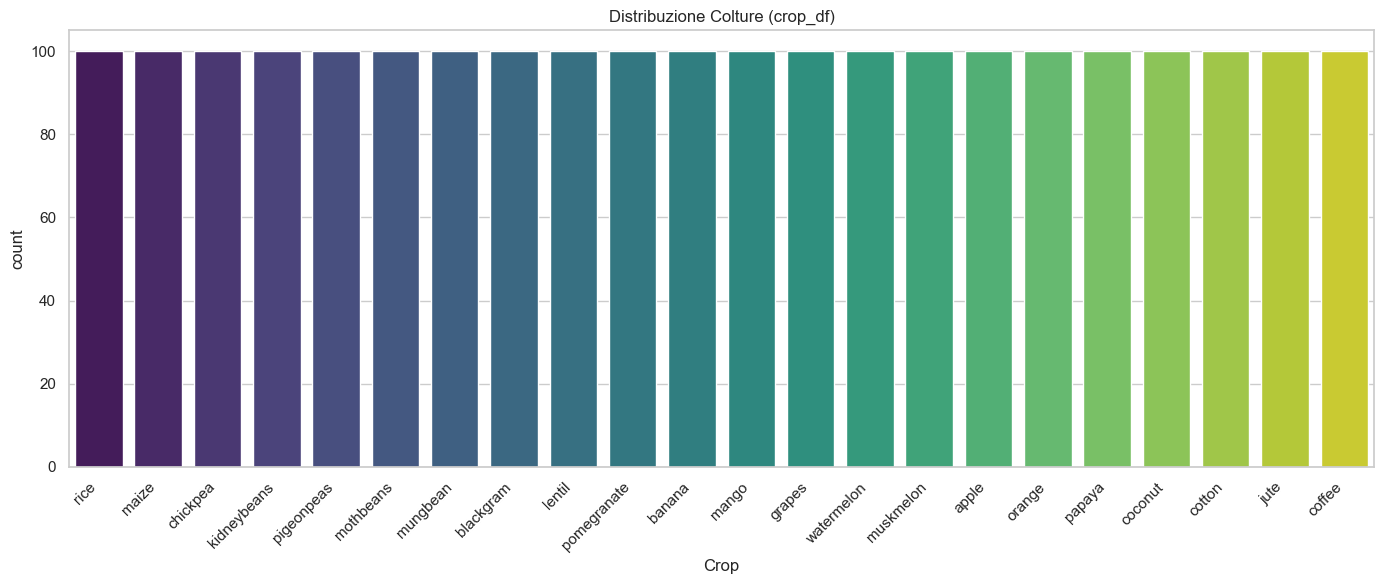

In [148]:
plt.figure(figsize=(14, 6))
sns.countplot(data=crop_df, x='Crop', hue='Crop', palette='viridis', order=crop_df["Crop"].value_counts().index)
plt.title("Distribuzione Colture (crop_df)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

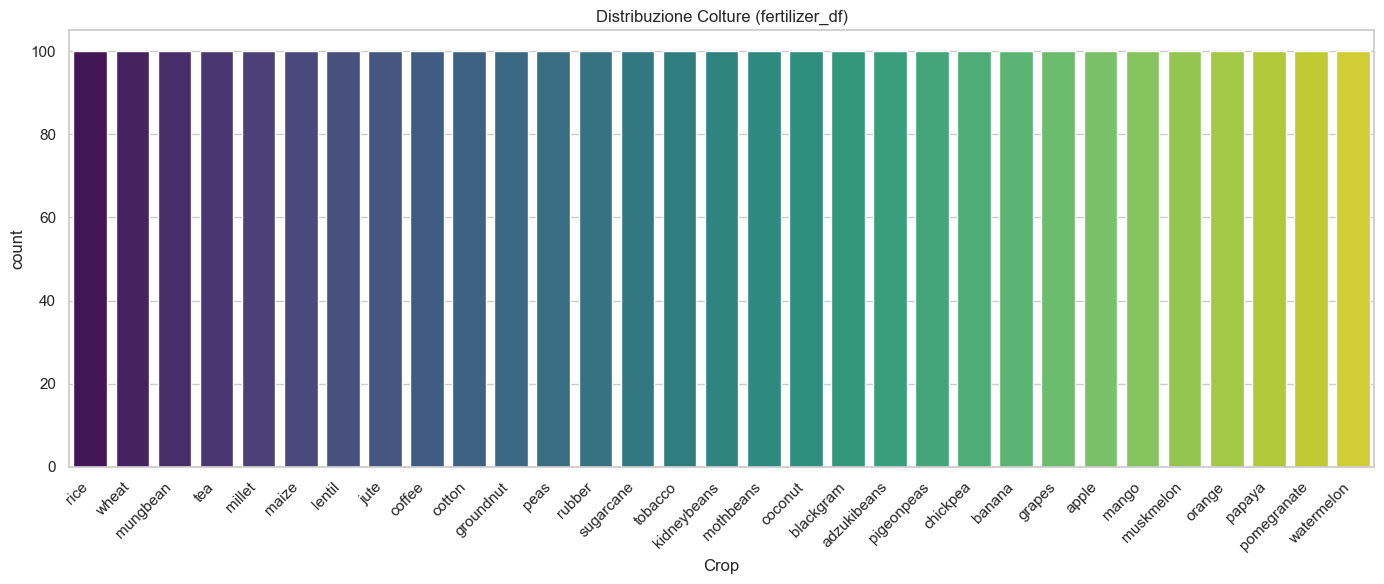

In [149]:
plt.figure(figsize=(14, 6))
sns.countplot(data=fertilizer_df, x='Crop', hue='Crop', palette='viridis', order=fertilizer_df["Crop"].value_counts().index)
plt.title("Distribuzione Colture (fertilizer_df)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Text(0.5, 0, 'Humidity (ratio)')

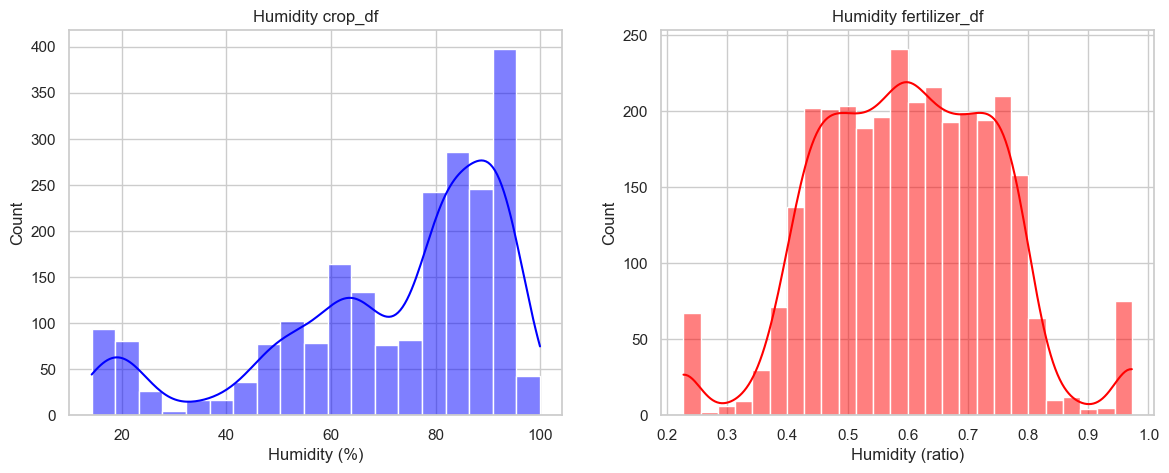

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(crop_df["Humidity"], kde=True, color='blue', ax=axes[0])
axes[0].set_title('Humidity crop_df', fontsize=12)
axes[0].set_xlabel('Humidity (%)')

sns.histplot(fertilizer_df["Moisture"], kde=True, color='red', ax=axes[1])
axes[1].set_title('Humidity fertilizer_df', fontsize=12)
axes[1].set_xlabel('Humidity (ratio)')

Ci sono ben 9 dati non mappati tra i due dataset ed in più alcune colonne specificate prima non hanno lo stesso nome(pH_value != PH) e la stessa scala(i.e. humidity -> in percentuale (72%), Moisture -> in proporzione (0.72)). In compenso notiamo che:
- Temperature -> °C
- Nitrogen, Phosphorous, Carbon, Potassium -> mg/kg
- pH -> misura adimensionale standard (da 0 a 14)
- Rainfall -> mm
- Soil, Carbon non sono comuni (ovvero non sono presenti in `crop_df`)
- Remark è possibile ignorarla per il momento
- Hanno 100 esemplari per coltura

In [ ]:
map_names = {
    "Moisture": "Humidity",
    "PH" : "pH_Value",
    "Phosphorous" : "Phosphorus"
}

fertilizer_df = fertilizer_df.rename(columns=map_names)
fertilizer_df["Humidity"] = fertilizer_df["Humidity"] * 100 # Per evitare problemi con la divisione

In [152]:
fertilizer_df

,Temperature,Humidity,Rainfall,pH_Value,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,72.589298,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,72.195809,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,68.575095,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,75.509467,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,73.067235,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
3095,23.486430,53.119125,46.412228,6.733584,56.534283,146.111078,81.389366,1.602913,Neutral Soil,watermelon,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3096,24.289508,73.669910,63.068103,6.372709,56.358005,49.003277,46.695889,1.473656,Peaty Soil,watermelon,DAP,"Rich in phosphorus, essential for root develop..."
3097,23.945488,52.051304,41.344590,7.051515,55.738905,148.567285,90.057021,1.455045,Neutral Soil,watermelon,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3098,26.368604,54.743622,33.106012,6.615922,57.711705,96.662953,59.531473,0.614487,Acidic Soil,watermelon,Compost,Enhances organic matter and improves soil stru...


In [153]:
crop_df

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
